Extracting whole-brain maps:	schaefer...	tian_subcortex...	cerebellum...	brainstem...Saving... Done
Converting volumetric data to surface...
Plotting surface data...
Plot saved to: ../fig\results_gradientboost_cortex.png


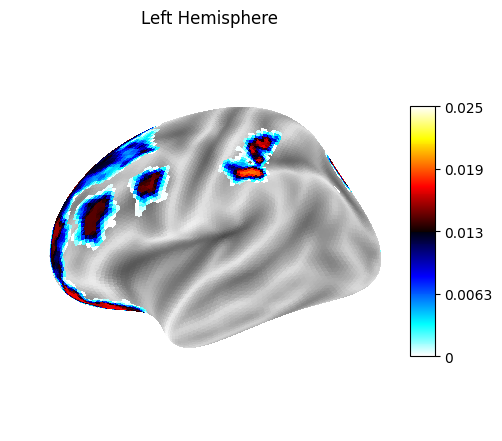

In [1]:
import pandas as pd
import numpy as np
import os

import nibabel as nb
from nilearn.image import load_img, math_img
from nilearn.datasets import load_mni152_template, fetch_surf_fsaverage
from nilearn import plotting, surface, datasets

import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import cm
from nilearn.plotting.cm import _cmap_d as nilearn_cmaps

from neuromaps.datasets import fetch_fslr
from neuromaps.transforms import mni152_to_fslr
from surfplot import Plot
from surfplot.utils import threshold

#from plot import extract_results_wrapper, plot_surf, plot_subcortex, plot_colorbar

template = load_mni152_template(resolution=1)

# Wrapper for extracting tmaps
def extract_results_wrapper(df, stat, atlases_nii, atlases_csv, save_path):
    """
    Extract and save whole-brain maps as NIfTI files.

    Parameters:
        df (pandas.DataFrame): DataFrame containing ROI-level results.
        stat (str): Statistic to extract.
        atlases_nii (dict): Dictionary with atlas names as keys and their NIfTI images as values.
        atlases_csv (dict): Dictionary with atlas names as keys and their CSV files as values.
        save_path (str): Path to save the whole-brain T-maps.

    Returns:
        nilearn.image.Nifti1Image: The generated whole-brain T-map.
    """

    print('Extracting whole-brain maps', end = ':')
    # Define atlas names
    parcels_maps = ['schaefer', 'tian_subcortex', 'cerebellum']
    # Extract T-maps for each atlas
    tmaps = {selected_atlas: vals2atlas(df, selected_atlas, atlases_nii, atlases_csv, stat) for selected_atlas in parcels_maps}

    # Handle brainstem separately
    print('\tbrainstem', end = '...')
    df_brainstem_results = df[df['Atlas'] == 'brainstem']
    if df_brainstem_results.empty:
        tmap_brainstem_zeros = np.zeros(shape = tmaps['schaefer'].shape)
        tmaps['brainstem'] = nb.Nifti1Image(tmap_brainstem_zeros, header = tmaps['schaefer'].header, affine = tmaps['schaefer'].affine) 
    else:
        tmaps_brainstem = [val2roi_atlas(df_brainstem_results, brainstem_roi, atlases_nii, stat) for brainstem_roi in df_brainstem_results['ROI'].tolist()]
        tmaps['brainstem'] = math_img('np.sum(img, axis=-1)', img = tmaps_brainstem)


    # Combine brain maps
    tmaps['tian_subcortex_brainstem'] = math_img('np.sum(img, axis=-1)', img = [tmaps['tian_subcortex'], tmaps['brainstem']])
    tmaps['wholebrain'] = math_img('np.sum(img, axis=-1)', img = [tmaps['schaefer'], tmaps['tian_subcortex'], tmaps['brainstem'], tmaps['cerebellum']])

    # Save T-map
    print('Saving...', end=' ')
    for suffix, data in tmaps.items():
        file_path = os.path.join(f'{save_path}_{suffix}.nii.gz')
        nb.save(data, file_path)
    
    print('Done')
    
    return tmaps['wholebrain']


def vals2atlas(df, selected_atlas, atlases_nii, atlases_csv, stat):
    """
    Puts statistical values from a DataFrame to an atlas. Takes only Schaefer, Tian Subcortex, and MDTB Cerebellum atlases.

    Parameters:
        df (pandas.DataFrame): DataFrame containing ROI-level results.
        selected_atlas (str): Name of the selected atlas.
        atlases_nii (dict): Dictionary of NIfTI paths for different atlases.
        atlases_csv (dict): Dictionary of CSV paths containing atlas information.
        stat (str): Statistic to extract.

    Returns:
        nilearn.image.Nifti1Image: The modified atlas.
    """
    print(f'\t{selected_atlas}...', end = '')

    # Load atlas
    selected_atlas_img = load_img(atlases_nii[selected_atlas])
    selected_atlas_img_np = selected_atlas_img.get_fdata()

    n_labels = np.unique(selected_atlas_img_np)[1:]

    atlas_info = pd.read_csv(atlases_csv[selected_atlas])
    atlas_labels = atlas_info['Label Name'].tolist()

    # Subset results data frame and get ROIs
    results_selected_atlas = df[df['Atlas'] == selected_atlas]
    df_atlas_sig_rois = results_selected_atlas.ROI.tolist()

    for i in n_labels:
        # Check if label is in model
        label_i = atlas_labels[int(i) - 1]
        label_contains = label_i in df_atlas_sig_rois
        selected_atlas_img_np[selected_atlas_img_np == i] = 0 if not label_contains else results_selected_atlas.iloc[df_atlas_sig_rois.index(label_i)][stat]

    tmap = nb.Nifti1Image(selected_atlas_img_np, header = selected_atlas_img.header, affine = selected_atlas_img.affine)
    
    return tmap

def val2roi_atlas(df, brainstem_roi, atlases_nii, stat):
    """
    Puts statistical values from a DataFrame to a specific ROI. Works only for individual ROIs like the brainstem.

    Parameters:
        df (pandas.DataFrame): DataFrame containing ROI-level results.
        brainstem_roi (str): Name of the ROI within the brainstem atlas.
        atlases_nii (dict): Dictionary of NIfTI paths for different atlases.
        stat (str): Statistic to extract.

    Returns:
        nilearn.image.Nifti1Image: The modified ROI within the atlas.
    """
    df_brainstem_i = df[df['ROI'] == brainstem_roi]
    i_roi = load_img(os.path.join(atlases_nii['brainstem'], brainstem_roi + '.nii.gz'))
    i_roi_np = i_roi.get_fdata()
    i_roi_np[i_roi_np == 1] = df_brainstem_i[stat].tolist()[0]

    tmap = nb.Nifti1Image(i_roi_np, header = i_roi.header, affine = i_roi.affine)

    return tmap

def plot_fig(tmap, nrow, ncol, figsize, annotate = False, save = False, close = False, 
             display_mode = 'x', labelsize = 12, orientation = 'vertical', cbar_label = 'ReHo Difference', plot_save_path = 'figure.png'):
    """
    Plot multiple slices of a 3D statistical map.

    Parameters:
        tmap (array): 3D statistical map or file path to map.
        nrow (int): Number of rows in the plot grid.
        ncol (int): Number of columns in the plot grid.
        figsize (tuple): Figure size (width, height) in inches.
        annotate (bool, optional): Whether to annotate the plot. Default is False.
        save (bool, optional): Whether to save the plot. Default is False.
        close (bool, optional): Whether to close the plot after saving. Default is False.
        display_mode (str, optional): Display mode for the slices ('x', 'y', or 'z'). Default is 'x'.
        labelsize: Font size for labels on the colorbar.
        orientation: Orientation of the colorbar ('vertical' or 'horizontal').
        plot_save_path (str, optional): File path for saving the plot. Default is 'figure.png'.

    Returns:
        fig (Figure): The generated matplotlib figure.
        axes (array of Axes): Array of axes objects for the subplots.
    """

    if isinstance(tmap, str):
        img = nb.load(tmap)
    else:
        img = tmap

    cut_coords = {
        'x': np.linspace(-60, 60, ncol * nrow, dtype=int).tolist(),
        'y': np.linspace(-100, 70, ncol * nrow, dtype=int).tolist(),
        'z': np.linspace(-62, 72, ncol * nrow, dtype=int).tolist()
    }
    print(f'Display mode: {display_mode}, \nCoordinates: {cut_coords[display_mode]}')
    # Set counter
    counter = 0

    # Start plotting
    fig, axes = plt.subplots(nrow, ncol+1, figsize = figsize, gridspec_kw={'width_ratios': [1]*ncol + [0.05]})
    gs = axes[0, ncol].get_gridspec()
    # remove the underlying axes
    for ax in axes[0:, -1]:
        ax.remove()
    ax_colorbar = fig.add_subplot(gs[0:, -1])

    # Do the brain map 
    for row in range(0, nrow):
        for col in range(0, ncol):
            plotting.plot_stat_map(img, title = '', black_bg = True, bg_img = template,
                                   axes = axes[row, col], annotate = annotate, 
                                   display_mode = display_mode, symmetric_cbar = True,
                                   colorbar = False, cut_coords = [cut_coords[display_mode][counter]])
            counter += 1

    # Do the colorbar
    font_properties = {'family': 'serif', 'size': labelsize}
    cmap = cm.get_cmap('cold_hot')
    fdata = img.get_fdata()
    fdata_max = np.abs(fdata).max()
    # Add a little bit of padding to the max value
    vmax_f = fdata_max + (fdata_max * 0.05)
    norm = mpl.colors.Normalize(vmin = -vmax_f, vmax = vmax_f)

    cb1 = mpl.colorbar.ColorbarBase(ax_colorbar, cmap = cmap, norm = norm, orientation = orientation)
    cb1.set_label(cbar_label)
    cb1.ax.tick_params(labelsize = labelsize)
    cb1.ax.set_yticklabels(cb1.ax.get_yticklabels(), **font_properties)
    
    if save:
        plt.savefig(plot_save_path, dpi = 300, bbox_inches = 'tight')
        
    if close:
        plt.close()
        
    return fig, axes

def plot_single_roi_stat(in_file, out_file, display_mode, black_bg, cut_coords):
    """
    Plot a statistical map for a single region of interest (ROI).

    Parameters:
    - in_file (str): Input file path containing the statistical map.
    - out_file (str): Output file path to save the generated plot.
    - display_mode (str): The display mode for the plot (e.g., 'z', 'x', 'y').
    - cut_coords (tuple): Tuple of coordinates to indicate the location of the cuts.

    Returns:
    - matplotlib.figure.Figure: The Figure object representing the generated plot.

    Example:
    >>> plot_single_roi_stat('stat_map.nii.gz', 'roi_plot.png', 'z', (0, 0, 0))
    """
    
    img = nb.load(in_file)
    data = img.get_fdata()
    # Get absolute max value
    abs_max = np.max(np.abs(data))
    # Add buffer for max value
    abs_max = abs_max + abs_max * 0.1

    fig, axes = plt.subplots(1, 1, figsize = (4, 4))

    return plotting.plot_stat_map(img, output_file = out_file, symmetric_cbar = True, vmax = abs_max, 
                                  bg_img = template, black_bg = black_bg,
                                  cut_coords = cut_coords, figure = fig, axes = axes,
                                  display_mode = display_mode)

def save_and_show_plot(fig_brain, filepath_base):
    plt.tight_layout()
    plt.savefig(f'{filepath_base}.svg', dpi=300, bbox_inches='tight')
    plt.savefig(f'{filepath_base}.png', dpi=300, bbox_inches='tight')
    plt.show()

# Plot surface plot
def plot_surf(tmap, savefile, vmax=None, cmap=None, show_figure=False):

    # project from MNI to fslr and threshold after projection to avoid interpolation artefacts
    gii_lh, gii_rh = mni152_to_fslr(tmap)
    data_lh = threshold(gii_lh.agg_data(), 0.001)
    data_rh = threshold(gii_rh.agg_data(), 0.001)

    # get surfaces + sulc maps
    surfaces = fetch_fslr()
    lh, rh = surfaces['inflated']
    sulc_lh, sulc_rh = surfaces['sulc']

    p = Plot(lh, rh)
    p.add_layer({'left': sulc_lh, 'right': sulc_rh}, cmap='binary_r', cbar=False)

    # cold_hot is a common diverging colormap for neuroimaging
    img_np = tmap.get_fdata()
    if vmax is None:
        vmax = np.max(np.abs(img_np)) * 1.05
    if cmap is None:
        cmap = nilearn_cmaps['cold_hot']
    p.add_layer({'left': data_lh, 'right': data_rh}, cmap=cmap, color_range=(-vmax, vmax))

    # make a nice vertical colorbar on the right side of the figure
    kws = dict(location='right', draw_border=True, aspect=5, shrink=0.2,
            decimals=3, pad=0)
    fig = p.build(cbar_kws=kws)
    fig.savefig(savefile, bbox_inches='tight', dpi=1200, transparent=True)
    if show_figure:
        fig.show()
    else:
        plt.close(fig)

# Plot subcortex
def plot_subcortex(tmap_wholebrain, vmax, cut_coords, display_mode, dirs, control_tasks):
    
    template = load_mni152_template(resolution=1)
    # Set up analysis_type parameters
    width_multiplier = 2
    height_multiplier = 2

    # Set up plot
    widths = [2] * width_multiplier
    heights = [3] * height_multiplier

    fig_brain, axes_brain = plt.subplots(ncols=len(widths), nrows=len(heights), figsize=(sum(widths), sum(heights)))
    fig_brain.patch.set_alpha(0)
    for ax in axes_brain.flatten():
        ax.patch.set_alpha(0)

    # Start plotting
    row_counter = 0
    for task in control_tasks:
        vmax_task = vmax[task]
        tmap = tmap_wholebrain[task]
        file_in_basename = f'NS_comparison_{task}_tian_subcortex_brainstem.nii.gz'
        file_in = os.path.join(dirs['stat'], 'maps', file_in_basename)
        tmap = nb.load(file_in)
        for col in range(width_multiplier):
            plotting.plot_stat_map(tmap, title='', black_bg=False, annotate=False, bg_img=template,
                                    axes=axes_brain[row_counter, col] if width_multiplier > 1 else axes_brain[row_counter],
                                    vmax=vmax_task, display_mode=display_mode[task][col], symmetric_cbar=True,
                                    colorbar=False, cut_coords=[cut_coords[task][col]])
        row_counter += 1

    save_and_show_plot(fig_brain, os.path.join(dirs['figs'], 'NS_ReHo_compare_subcortex_brainstem'))

# Plot colorbar
def plot_colorbar(colormap, vmax, figsize, orientation, save, plot_save_path):
    ''' 
    creates and returns a colorbar for each network.
    
    
    Parameters
    ----------
    network_tmaps: dictionary of tmaps for each network
    trend: str of either Linear, Quadratic, or Cubic trends
    network: str of Vis, SomMot, Cont, VentAtt, DorsAttn, Default, Limbic, tian_subcortex, brainstem, cerebellum
    figsize: tuple. (0.5, 7)
    orientation: str. horizontal or vertical
    
    Returns
    ----------
    colorbar
    '''

    fig_bar, ax_bar = plt.subplots(figsize=figsize)

    cmap = cm.get_cmap(colormap)
    norm = mpl.colors.Normalize(vmin=-vmax, vmax=vmax)

    cb1 = mpl.colorbar.ColorbarBase(ax_bar, cmap=cmap, norm=norm, orientation=orientation)
    
    # Remove tick marks and labels
    cb1.ax.tick_params(labelsize=0, length=0)
    cb1.set_ticks([])

    # Set the figure background to transparent
    fig_bar.patch.set_facecolor('none')
    fig_bar.patch.set_alpha(0)
      
    if save:        
        plt.savefig(plot_save_path, dpi = 300, bbox_inches = 'tight')  
    
    return fig_bar, ax_bar

# Attempt to fetch fsaverage directly here with error handling
try:
    fsaverage = datasets.fetch_surf_fsaverage()
except AttributeError as e:
    print("Error fetching fsaverage. Check Nilearn installation. Error:", e)
    fsaverage = None

# Set up directories and files
dirs = {
    'atlas': '../atlas',
    'stat': '../stat',
    'fig': '../fig',
    'stat_maps': '../stat/maps'
}

atlases_nii = {
    'schaefer': os.path.join(dirs['atlas'], 'schaefer', 'Reslice_400Parcels_7Networks.nii.gz'),
    'tian_subcortex': os.path.join(dirs['atlas'], 'tian_subcortex', 'Reslice_tian_subcortex_S2_7T.nii.gz'),
    'cerebellum': os.path.join(dirs['atlas'], 'cerebellum', 'Reslice_MDTB10-cerebellum.nii.gz'),
    'brainstem': os.path.join(dirs['atlas'], 'brainstem', 'resampled_rois/')
}
atlases_csv = {
    'schaefer': os.path.join(dirs['atlas'], 'schaefer', '400parcels_7networks.csv'),
    'tian_subcortex': os.path.join(dirs['atlas'], 'tian_subcortex', 'tian_subcortex_S2.csv'),
    'brainstem': os.path.join(dirs['atlas'], 'brainstem', 'brainstem_54.csv'),
    'cerebellum': os.path.join(dirs['atlas'], 'cerebellum', 'MDTB10-cerebellum.csv')
}

# Create toggles
toggles = {
    'create_tmaps': False,
    'plot_cortex': True,
    'plot_subcortex': True,
    'plot_colorbar': True,
}

ML_algorithm = 'gradientboost'
df_results = pd.read_csv(os.path.join(dirs['stat'], 'test.csv'))
df_results['ROI'] = df_results['ROI'].str.replace('.', '-')
score_filter = 0.01
df_results = df_results[(df_results['Weights'] > score_filter) | (df_results['Weights'] < -score_filter)]
output_path = os.path.join(dirs['stat'], 'maps', f'results_{ML_algorithm}')

# Extract results into brain
tmap_wholebrain = extract_results_wrapper(df_results, 'Weights', atlases_nii, atlases_csv, output_path)

if toggles['plot_cortex']:
    schaefer_results = os.path.join(dirs['stat'], 'maps', f'results_{ML_algorithm}_schaefer.nii.gz')
    tmap_schaefer = nb.load(schaefer_results)

    if not isinstance(tmap_schaefer, (nb.Cifti2Image, nb.GiftiImage)) and fsaverage is not None:
        print("Converting volumetric data to surface...")
        texture = surface.vol_to_surf(tmap_schaefer, fsaverage.pial_left)
        print("Plotting surface data...")
        display = plotting.plot_surf_stat_map(fsaverage.infl_left, texture, hemi='left',
                                              title='Left Hemisphere', colorbar=True, threshold=1e-16,
                                              bg_map=fsaverage.sulc_left, view='lateral')
        savefile = os.path.join(dirs['fig'], f'results_{ML_algorithm}_cortex.png')
        plt.savefig(savefile)  # Using matplotlib to save the plot
        print("Plot saved to:", savefile)
        display  # This line will display the plot in the notebook
    elif fsaverage is not None:
        savefile = os.path.join(dirs['fig'], f'results_{ML_algorithm}_cortex.png')
        plot_surf(tmap_schaefer, savefile, vmax=None, cmap=None, show_figure=True)
    else:
        print("Unable to plot: fsaverage data not available.")
